# Default XGBoost Classifier

Baseline notebook for training an `XGBClassifier` on `Tommy_Award_Player_Game_Table_hustle.csv` with the same train/validation/test season setup used in your other notebooks.

In [2]:
from pathlib import Path
import random

import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

csv_path = Path("Tommy_Award_Player_Game_Table_hustle.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find dataset at: {csv_path.resolve()}")

df = pd.read_csv(csv_path)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns from {csv_path.name}")
df.head()

Loaded 8,530 rows and 60 columns from Tommy_Award_Player_Game_Table_hustle.csv


,gameId,teamId,teamCity,teamName,teamTricode,teamSlug,personId,firstName,familyName,nameI,...,assists_rank,steals_rank,blocks_rank,plusMinusPoints_rank,minutes_decimal_rank,deflections,deflections_missing,charges_drawn,charges_drawn_missing,usage_rate
0,21600006,1610612738,Boston,Celtics,BOS,celtics,203109,Jae,Crowder,J. Crowder,...,7.0,2.0,4.0,4.0,3.0,4.0,0,0.0,0,0.00227
1,21600006,1610612738,Boston,Celtics,BOS,celtics,101161,Amir,Johnson,A. Johnson,...,7.0,5.0,5.0,3.0,6.0,3.0,0,0.0,0,0.00185
2,21600006,1610612738,Boston,Celtics,BOS,celtics,201143,Al,Horford,A. Horford,...,2.0,8.0,1.0,2.0,5.0,1.0,0,0.0,0,0.00145
3,21600006,1610612738,Boston,Celtics,BOS,celtics,202340,Avery,Bradley,A. Bradley,...,2.0,5.0,5.0,4.0,1.0,4.0,0,0.0,0,0.00222
4,21600006,1610612738,Boston,Celtics,BOS,celtics,202738,Isaiah,Thomas,I. Thomas,...,1.0,2.0,5.0,1.0,2.0,2.0,0,0.0,0,0.00253


In [3]:
target_col = "y"
numeric_feature_cols = [
    "minutes_decimal",
    "points",
    "reboundsOffensive",
    "reboundsDefensive",
    "reboundsTotal",
    "assists",
    "steals",
    "blocks",
    "deflections",
    "charges_drawn",
    "turnovers",
    "foulsPersonal",
    "plusMinusPoints",
    "net_rating",
    "usage_rate",
    "impact_efficiency",
    "role_outperformance",
    "fieldGoalsMade",
    "fieldGoalsAttempted",
    "threePointersMade",
    "threePointersAttempted",
    "freeThrowsMade",
    "stocks",
    "points_per_min",
    "oreb_per_min",
    "reb_per_min",
    "ast_per_min",
    "stocks_per_min",
    "hustle_proxy",
    "points_rank",
    "reboundsOffensive_rank",
    "reboundsTotal_rank",
    "assists_rank",
    "steals_rank",
    "blocks_rank",
    "plusMinusPoints_rank",
    "minutes_decimal_rank",
    "stocks_rank",
    "hustle_proxy_rank",
]

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataframe.")

if "GAME_ID" in df.columns:
    game_id_col = "GAME_ID"
elif "gameId" in df.columns:
    game_id_col = "gameId"
else:
    raise ValueError("Could not find game id column (expected GAME_ID or gameId).")

if "game_date" in df.columns:
    df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce", format="mixed")

if "season" not in df.columns:
    if "game_date" not in df.columns:
        raise ValueError("Need either 'season' or 'game_date' to derive seasons.")
    start_year = df["game_date"].dt.year.where(df["game_date"].dt.month >= 10, df["game_date"].dt.year - 1)
    df["season"] = start_year.astype("Int64").astype(str) + "-" + (start_year + 1).astype("Int64").astype(str).str[-2:]

# Match other notebooks: keep only players who logged minutes.
df = df[df["minutes_decimal"] > 0].copy()
mins = df["minutes_decimal"].clip(lower=1e-6)

# Recreate derived columns used by shared feature list when missing.
if "net_rating" not in df.columns:
    df["net_rating"] = pd.to_numeric(df["plusMinusPoints"], errors="coerce")
if "stocks_per_min" not in df.columns:
    df["stocks_per_min"] = pd.to_numeric(df["stocks"], errors="coerce") / mins

eps = 1e-6
if "impact_efficiency" not in df.columns:
    df["impact_efficiency"] = pd.to_numeric(df["net_rating"], errors="coerce") / (pd.to_numeric(df["usage_rate"], errors="coerce") + eps)
if "role_outperformance" not in df.columns:
    df["role_outperformance"] = pd.to_numeric(df["net_rating"], errors="coerce") * (1 - pd.to_numeric(df["usage_rate"], errors="coerce"))
if "stocks_rank" not in df.columns:
    df["stocks_rank"] = df.groupby(game_id_col)["stocks"].rank(method="min", ascending=False)
if "hustle_proxy_rank" not in df.columns:
    df["hustle_proxy_rank"] = df.groupby(game_id_col)["hustle_proxy"].rank(method="min", ascending=False)

missing_cols = [col for col in numeric_feature_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing feature columns: {missing_cols}")

print(f"Rows after minutes filter: {len(df):,}")
print(f"Numeric features: {len(numeric_feature_cols)}")

Rows after minutes filter: 8,495
Numeric features: 39


In [4]:
requested_test_seasons = ["2024-25", "2025-26"]
available_seasons = sorted(df["season"].dropna().astype(str).unique().tolist())
selected_test_seasons = [s for s in requested_test_seasons if s in available_seasons]

if not selected_test_seasons:
    raise ValueError(
        f"None of the requested test seasons were found. Requested={requested_test_seasons}, available={available_seasons}"
    )

train_df = df[~df["season"].isin(selected_test_seasons)].copy()
test_df = df[df["season"].isin(selected_test_seasons)].copy()

# Temporal validation split inside train_df: latest train season is validation.
train_seasons = sorted(train_df["season"].dropna().astype(str).unique().tolist(), key=lambda s: int(s.split("-")[0]))
if len(train_seasons) < 2:
    raise ValueError("Need at least 2 train seasons to create train/validation split.")

val_season = train_seasons[-1]
fit_train_df = train_df[train_df["season"].isin(train_seasons[:-1])].copy()
val_df = train_df[train_df["season"] == val_season].copy()

summary_df = pd.DataFrame(
    {
        "item": [
            "rows",
            "numeric_features",
            "categorical_features",
            "fit_train_games",
            "validation_games",
            "test_games",
            "fit_train_positive_rate",
            "validation_season",
            "test_seasons",
            "models",
        ],
        "value": [
            len(df),
            len(numeric_feature_cols),
            0,
            fit_train_df[game_id_col].nunique(),
            val_df[game_id_col].nunique(),
            test_df[game_id_col].nunique(),
            round(fit_train_df[target_col].mean(), 4),
            val_season,
            ", ".join(selected_test_seasons),
            "xgboost_optuna_tuned",
        ],
    }
)

display(summary_df)

,item,value
0,rows,8495
1,numeric_features,39
2,categorical_features,0
3,fit_train_games,547
4,validation_games,79
5,test_games,163
6,fit_train_positive_rate,0.0922
7,validation_season,2023-24
8,test_seasons,"2024-25, 2025-26"
9,models,xgboost_optuna_tuned


In [5]:
import optuna
from optuna.samplers import TPESampler
from xgboost import XGBClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
)

OPTUNA_TRIALS = 40
OPTUNA_TIMEOUT_SECONDS = 300
RANDOM_STATE = SEED

feature_medians = fit_train_df[numeric_feature_cols].median()
X_fit_train = fit_train_df[numeric_feature_cols].fillna(feature_medians)
y_fit_train = fit_train_df[target_col].astype(int)
X_val = val_df[numeric_feature_cols].fillna(feature_medians)
y_val = val_df[target_col].astype(int)
X_train_full = train_df[numeric_feature_cols].fillna(feature_medians)
y_train_full = train_df[target_col].astype(int)
X_test = test_df[numeric_feature_cols].fillna(feature_medians)
y_test = test_df[target_col].astype(int)


def score_game_topk(scored: pd.DataFrame, k: int) -> float:
    """Fraction of games where the true winner (y=1) is among the top-k rows by pred_prob."""

    def _game_hit(group: pd.DataFrame) -> bool:
        top = group.nlargest(k, "pred_prob")
        return bool((top[target_col] == 1).any())

    hits = scored.groupby(game_id_col, group_keys=False).apply(_game_hit)
    return float(hits.mean())


def top1_metrics(frame: pd.DataFrame, y_true: pd.Series, probs: np.ndarray) -> tuple[pd.DataFrame, pd.Series]:
    scored = frame.copy()
    scored["pred_prob"] = probs
    winner_idx_local = scored.groupby(game_id_col)["pred_prob"].idxmax()
    y_pred_top1_local = pd.Series(0, index=scored.index, dtype=int)
    y_pred_top1_local.loc[winner_idx_local] = 1

    metrics = {
        "game_top1_accuracy": scored.loc[winner_idx_local, target_col].mean(),
        "game_top3_accuracy": score_game_topk(scored, 3),
        "row_f1": f1_score(y_true, y_pred_top1_local, zero_division=0),
        "row_recall": recall_score(y_true, y_pred_top1_local, zero_division=0),
        "row_prauc": average_precision_score(y_true, scored["pred_prob"]),
        "row_logloss": log_loss(y_true, scored["pred_prob"], labels=[0, 1]),
        "row_brier": brier_score_loss(y_true, scored["pred_prob"]),
        "row_precision": precision_score(y_true, y_pred_top1_local, zero_division=0),
    }
    return pd.DataFrame([metrics]), y_pred_top1_local


def objective(trial: optuna.trial.Trial) -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 700),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 20.0),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 5.0, 20.0),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    candidate = XGBClassifier(**params)
    candidate.fit(X_fit_train, y_fit_train)
    val_probs = candidate.predict_proba(X_val)[:, 1]
    val_metrics, _ = top1_metrics(val_df, y_val, val_probs)
    return float(val_metrics.loc[0, "game_top1_accuracy"])


study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=OPTUNA_TRIALS, timeout=OPTUNA_TIMEOUT_SECONDS, show_progress_bar=True)

best_xgb_params = {
    **study.best_params,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

# Model for validation reporting (trained without validation season).
best_val_model = XGBClassifier(**best_xgb_params)
best_val_model.fit(X_fit_train, y_fit_train)
val_metrics_df, y_val_top1 = top1_metrics(val_df, y_val, best_val_model.predict_proba(X_val)[:, 1])

# Final model for test evaluation (trained on all non-test seasons).
model = XGBClassifier(**best_xgb_params)
model.fit(X_train_full, y_train_full)

scored_df = test_df.copy()
scored_df["pred_prob"] = model.predict_proba(X_test)[:, 1]
winner_idx = scored_df.groupby(game_id_col)["pred_prob"].idxmax()
y_test_top1 = pd.Series(0, index=scored_df.index, dtype=int)
y_test_top1.loc[winner_idx] = 1

test_metrics_df = pd.DataFrame(
    [
        {
            "game_top1_accuracy": scored_df.loc[winner_idx, target_col].mean(),
            "game_top3_accuracy": score_game_topk(scored_df, 3),
            "row_f1": f1_score(y_test, y_test_top1, zero_division=0),
            "row_recall": recall_score(y_test, y_test_top1, zero_division=0),
            "row_prauc": average_precision_score(y_test, scored_df["pred_prob"]),
            "row_logloss": log_loss(y_test, scored_df["pred_prob"], labels=[0, 1]),
            "row_brier": brier_score_loss(y_test, scored_df["pred_prob"]),
            "row_precision": precision_score(y_test, y_test_top1, zero_division=0),
        }
    ]
)

feature_importance_df = (
    pd.DataFrame({"feature": numeric_feature_cols, "importance": model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(f"Best Optuna validation game_top1_accuracy ({val_season}): {study.best_value:.4f}")
print("Best XGBoost hyperparameters:")
display(pd.DataFrame([best_xgb_params]))

print(f"Validation metrics ({val_season}):")
display(val_metrics_df)

print(f"Test metrics ({', '.join(selected_test_seasons)}):")
display(test_metrics_df)

print("Top 15 feature importances:")
display(feature_importance_df.head(15))

[I 2026-04-27 19:37:40,908] A new study created in memory with name: no-name-4727e0e5-c874-44df-be2f-f2943159b719


  0%|          | 0/40 [00:00<?, ?it/s]

/var/folders/bb/g3jnl_p57d11fvwjyxpcpwhc0000gn/T/ipykernel_16411/1926807031.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hits = scored.groupby(game_id_col, group_keys=False).apply(_game_hit)


[I 2026-04-27 19:37:42,266] Trial 0 finished with value: 0.34177215189873417 and parameters: {'n_estimators': 356, 'learning_rate': 0.17254716573280354, 'max_depth': 8, 'min_child_weight': 12.374511199743695, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_lambda': 0.0017775399007348214, 'gamma': 4.330880728874676, 'scale_pos_weight': 14.016725176148132}. Best is trial 0 with value: 0.34177215189873417.


/var/folders/bb/g3jnl_p57d11fvwjyxpcpwhc0000gn/T/ipykernel_16411/1926807031.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hits = scored.groupby(game_id_col, group_keys=False).apply(_game_hit)


...

,game_top1_accuracy,game_top3_accuracy,row_f1,row_recall,row_prauc,row_logloss,row_brier,row_precision
0,0.379747,0.746835,0.379747,0.379747,0.37956,0.383799,0.131169,0.379747


Test metrics (2024-25, 2025-26):


,game_top1_accuracy,game_top3_accuracy,row_f1,row_recall,row_prauc,row_logloss,row_brier,row_precision
0,0.398773,0.736196,0.398773,0.398773,0.336301,0.351379,0.118853,0.398773


Top 15 feature importances:


,feature,importance
0,fieldGoalsMade,0.210459
1,points,0.112297
2,points_rank,0.052364
3,hustle_proxy,0.034386
4,points_per_min,0.033260
5,hustle_proxy_rank,0.024972
6,plusMinusPoints_rank,0.023809
7,reboundsOffensive,0.022782
8,stocks,0.022175
9,reboundsTotal,0.021161


Confusion Matrix (Top-1 per game, test set):
[[1478   98]
 [  98   65]]


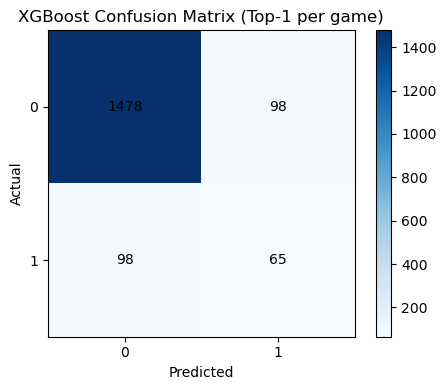

In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

print("Confusion Matrix (Top-1 per game, test set):")
cm = confusion_matrix(y_test, y_test_top1)
print(cm)

try:
    import seaborn as sns

    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title("XGBoost Confusion Matrix (Top-1 per game)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
except ModuleNotFoundError:
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title("XGBoost Confusion Matrix (Top-1 per game)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

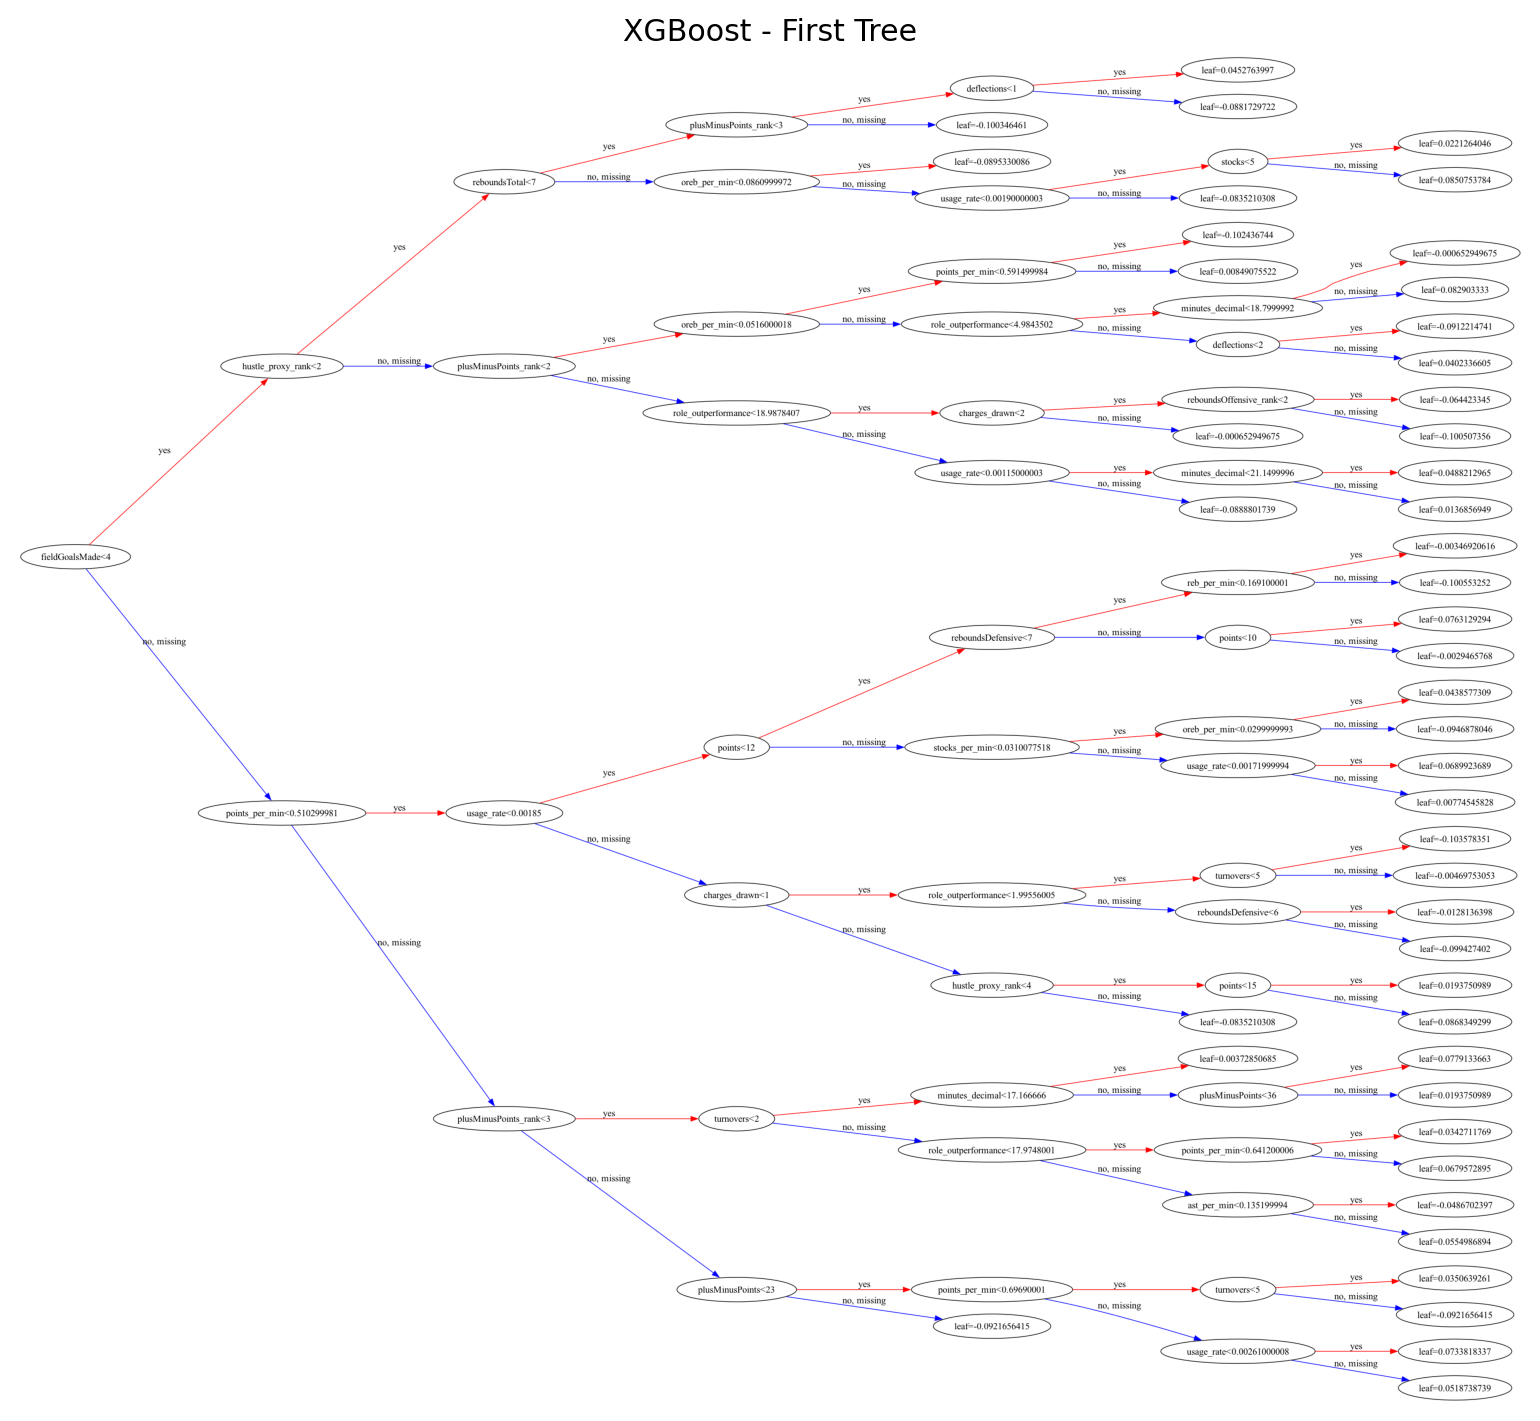

In [38]:
from xgboost import plot_tree
import matplotlib.pyplot as plt

# Visualize the first boosted tree in a more compact, readable layout.
try:
    fig, ax = plt.subplots(figsize=(28, 8), dpi=180)
    plot_tree(model, num_trees=0, rankdir="LR", ax=ax)
    ax.set_title("XGBoost - First Tree")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Graphviz is not installed, so tree visualization is skipped.")
    print("Install with: pip install graphviz  (and system graphviz if needed)")

    booster = model.get_booster()
    tree_text = booster.get_dump(with_stats=True)[0]
    print("\nFallback: text dump of first tree (first 40 lines):")
    print("\n".join(tree_text.splitlines()[:40]))